#SUMMARY OF MACHINE LEARNING PROJECT



In this assessment, I will implement a project titled Analyzing Movie Review Opinions from IMDB with Machine Learning. Specifically,the project investigates how computational models interpret the emotional tone expressed in user-generated movie reviews. Recently, online platforms such as IMDB have become important spaces for audience feedback, where personal reviews strongly influence both viewing choices and film reputation. Understanding these sentiments would offer valuable insights for filmmakers, production teams, and audiences.

There are two analytical models are applied in this project which are Logistic Regression, a regression-based classifier, and Naive Bayes, a probabilistic text model, aimed at classifying movie reviews by sentiment. Using NLP processes, written text is converted into measurable features, and the models’ accuracy and reliability are tested using standard performance metrics which are accuracy, precision, recall, F1-score.

# MOUNTING GOOGLE DRIVE

If you are opening this file on Google Collab, you have to run this. 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/ML assignment

/content/drive/MyDrive/ML assignment


# IMPORTING IMPORTANT LIBRARY

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import random

from scipy import sparse

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    roc_curve, auc, RocCurveDisplay
)

import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer




[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/minhhieu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/minhhieu/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/minhhieu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# 1.DATA PREPARATION

1.1 INITIALIZING THE DATASET

These codes above are being used when you are opening its on Google Collab. If you do not, just ignore it 

In [4]:
# Loading the data from CSV file
data_file = '/content/drive/MyDrive/ML assignment/IMDB Dataset.csv'
try:
    df = pd.read_csv(data_file, encoding='utf-8', delimiter=',')
    print('Data loaded successfully.')
except Exception as e:
    print('Error loading data:', e)

# Displaying the first few rows of the dataset
df.head()

Error loading data: [Errno 2] No such file or directory: '/content/drive/MyDrive/ML assignment/IMDB Dataset.csv'


NameError: name 'df' is not defined

In [2]:
df = pd.read_csv('IMDB Dataset.csv.zip')

In [3]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [5]:
print("Dataset shape:", df.shape)

Dataset shape: (50000, 2)


In [4]:
print("Columns:", df.columns.tolist())

Columns: ['review', 'sentiment']


1.2 VISUAL ANALYSIS OF SENTIMENT PATTERN

/var/folders/jy/0vdnv0tj33797_zjrdlnb5p40000gn/T/ipykernel_99517/116455041.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='Set3')


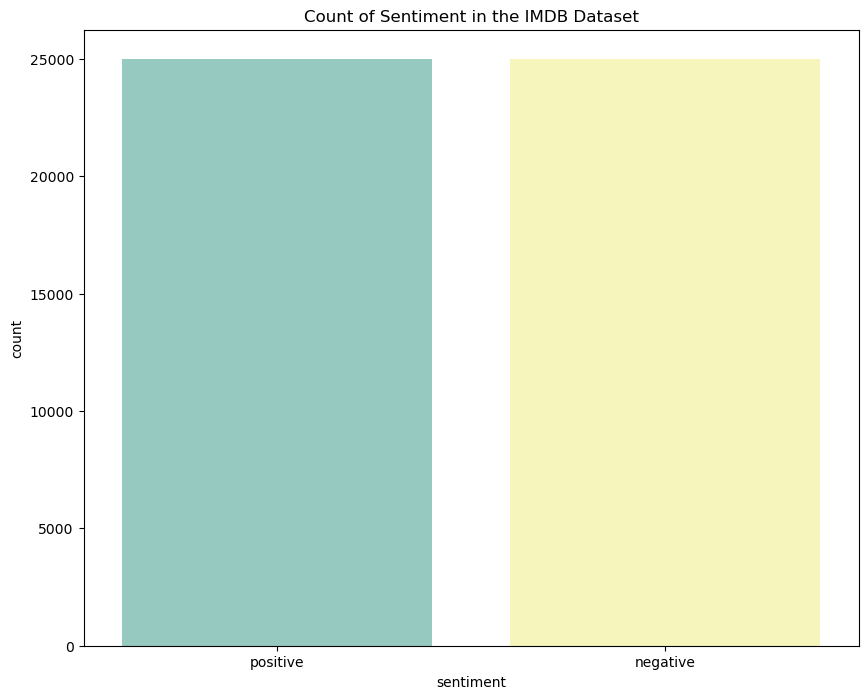

In [9]:
# A bar plot for the distribution of sentiment classes in the IMDB dataset.
plt.figure(figsize=(10, 8))
sns.countplot(x='sentiment', data=df, palette='Set3')
plt.title('Count of Sentiment in the IMDB Dataset', fontsize=12)
plt.show()

1.3 TEXT LENGTH EVALUATION

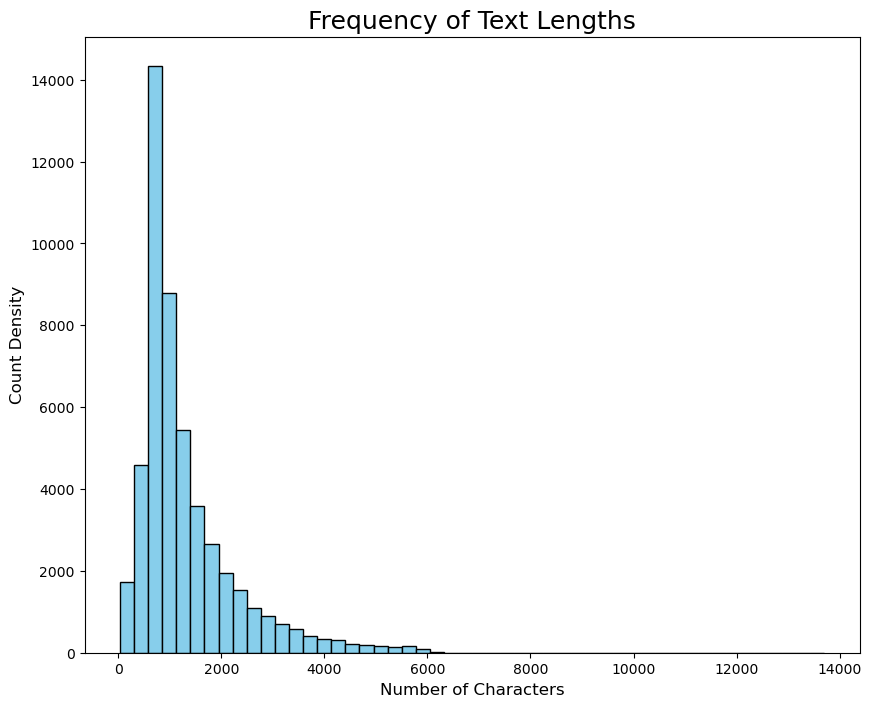

In [11]:
# Histogram for the distribution of review lengths in the dataset.
df['text_length'] = df['review'].apply(len)
plt.figure(figsize=(10,8))
plt.hist(df['review'].apply(len), bins=50, color='skyblue', edgecolor='black')
plt.title('Frequency of Text Lengths', fontsize=18)
plt.xlabel('Number of Characters', fontsize=12)
plt.ylabel('Count Density', fontsize=12)
plt.show()

In [12]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

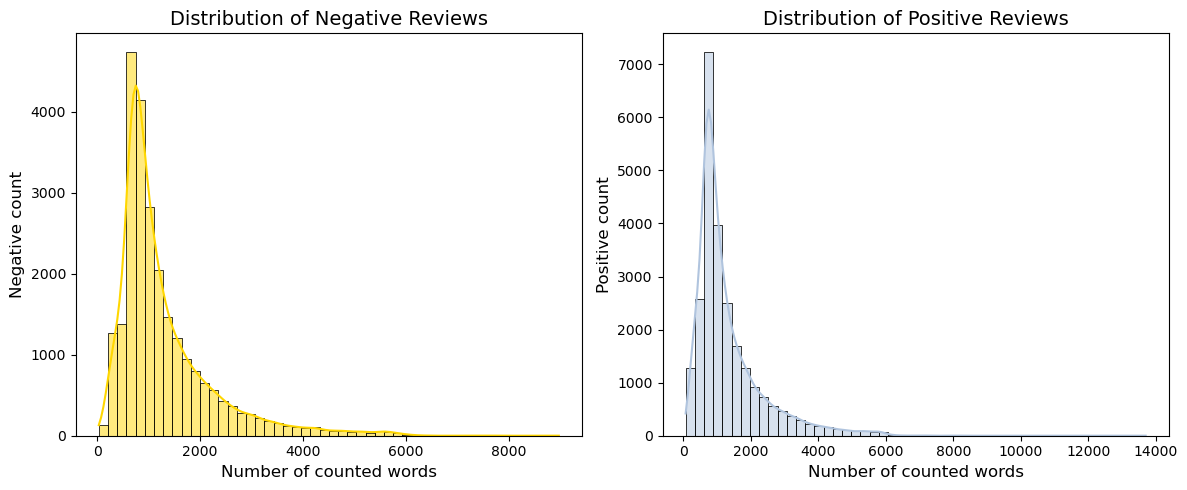

In [13]:
plt.figure(figsize=(12, 5))

# Histogram for Negative sentiment reviews
plt.subplot(1, 2, 1)
sns.histplot(df[df['sentiment'] == 0]['text_length'], bins=50, color='gold', kde=True)
plt.title('Distribution of Negative Reviews', fontsize=14)
plt.xlabel('Number of counted words', fontsize=12)
plt.ylabel('Negative count', fontsize=12)

# Histogram for Positive sentiment reviews
plt.subplot(1, 2, 2)
sns.histplot(df[df['sentiment'] == 1]['text_length'], bins=50, color='lightsteelblue', kde=True)
plt.title('Distribution of Positive Reviews', fontsize=14)
plt.xlabel('Number of counted words', fontsize=12)
plt.ylabel('Positive count', fontsize=12)

plt.tight_layout()
plt.show()

# 2. DATA HANDLING AND EXPLOTARY ANALYSIS

 2.1 MISSING DATA ANALYSIS

In [14]:
df.dropna(inplace=True)

In [15]:
df.isnull().values.any()

False

2.2 IDENTIFYING DUPLICATES

In [16]:
print("Total duplicate rows:", df.duplicated().sum())
df[df.duplicated()].head()

Total duplicate rows: 418


,review,sentiment,text_length
3537,Quite what the producers of this appalling ada...,0,2308
3769,My favourite police series of all time turns t...,1,488
4391,"Beautiful film, pure Cassavetes style. Gena Ro...",1,696
6352,If you liked the Grinch movie... go watch that...,0,548
6479,I want very much to believe that the above quo...,0,2750


In [17]:
duplicates = df[df.duplicated()]
if len(duplicates) > 0:
    print(f"Total: {len(duplicates)} duplicated rows")
    print(duplicates.head())
else:
    print("No duplicate rows found.")

Total: 418 duplicated rows
                                                 review  sentiment  \
3537  Quite what the producers of this appalling ada...          0   
3769  My favourite police series of all time turns t...          1   
4391  Beautiful film, pure Cassavetes style. Gena Ro...          1   
6352  If you liked the Grinch movie... go watch that...          0   
6479  I want very much to believe that the above quo...          0   

      text_length  
3537         2308  
3769          488  
4391          696  
6352          548  
6479         2750  


In [18]:
df = df.drop_duplicates()
df = df.drop_duplicates(keep='first')
df = df.drop_duplicates(keep='last')

2.3 ANALYZING OUTLIER

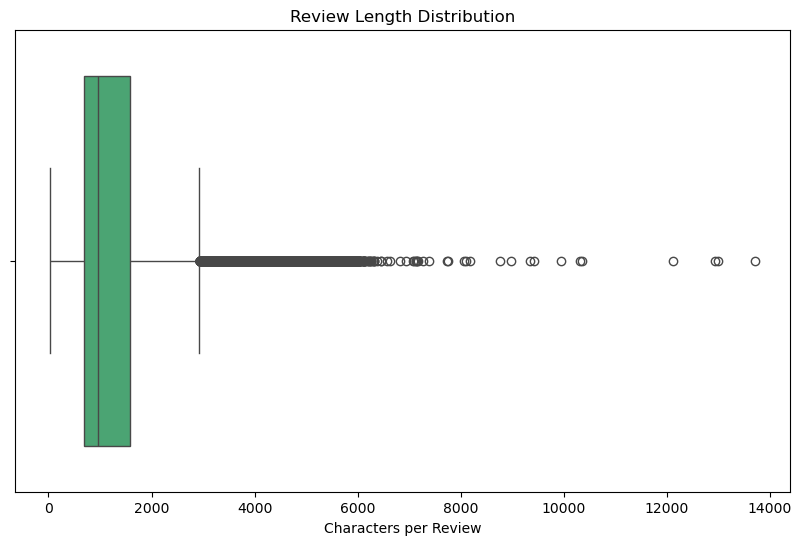

IQR: 893.0
Lower limit: -640.5
Upper limit: 2931.5
Outliers found: 3705

Some example outliers:
                                               review  text_length
26  "The Cell" is an exotic masterpiece, a dizzyin...         3149
29  'War movie' is a Hollywood genre that has been...         3791
33  One of the most significant quotes from the en...         4009
48  Preston Sturgis' THE POWER AND THE GLORY was u...         3975
51  ***SPOILERS*** All too, in real life as well a...         3371


In [19]:

df['text_length'] = df['review'].apply(len)

plt.figure(figsize=(10,6))
sns.boxplot(x=df['text_length'], color='mediumseagreen')
plt.title('Review Length Distribution')
plt.xlabel('Characters per Review')
plt.show()

q1 = df['text_length'].quantile(0.25)
q3 = df['text_length'].quantile(0.75)
iqr = q3 - q1

low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

print('IQR:', round(iqr, 2))
print('Lower limit:', round(low, 2))
print('Upper limit:', round(high, 2))


outliers = df[(df['text_length'] < low) | (df['text_length'] > high)]
print('Outliers found:', len(outliers))

if len(outliers) > 0:
    print('\nSome example outliers:')
    print(outliers[['review', 'text_length']].head())

df_clean = df[(df['text_length'] >= low) & (df['text_length'] <= high)].reset_index(drop=True)



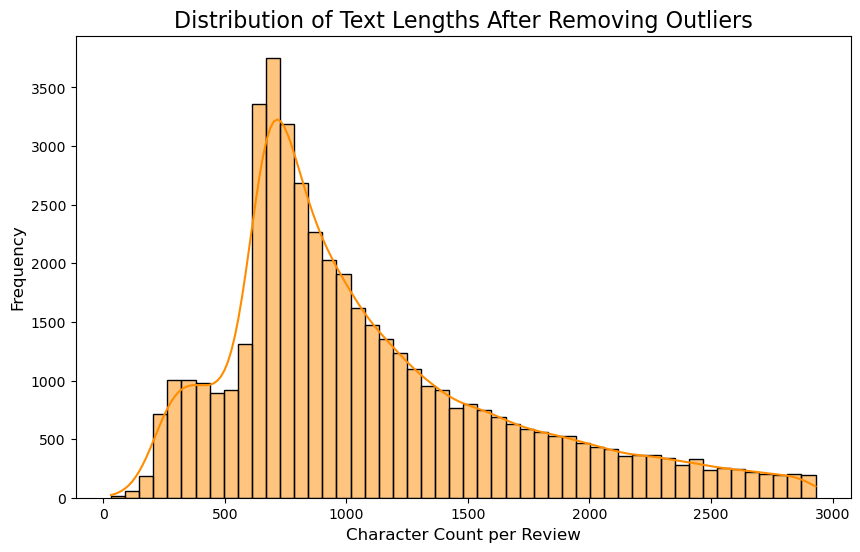

In [20]:

plt.figure(figsize=(10, 6))
sns.histplot(df_clean['text_length'], bins=50, kde=True, color='darkorange')
plt.title('Distribution of Text Lengths After Removing Outliers', fontsize=16)
plt.xlabel('Character Count per Review', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

2.4 TEXT DATA PREPROCESSING AND PREPARATION
(CLEANING - NORMALIZATION)

In [21]:
def prepare_text(text):
  return ' '.join([w for w in text.split() if w.lower() not in stopwords.words('english')])


In [22]:
df['review'] = df['review'].apply(prepare_text)

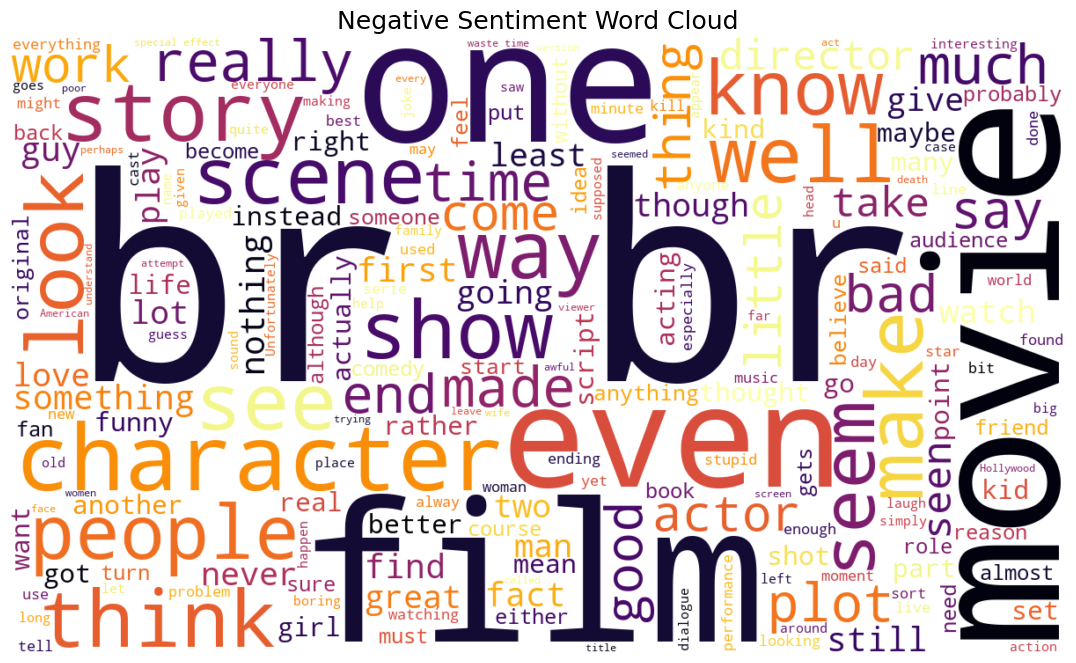

In [23]:
from wordcloud import WordCloud

neg_text = ' '.join(df.query('sentiment == 0')['review'].astype(str))

wordcloud = WordCloud(
    width=1200,
    height=700,
    max_words=200,
    colormap='inferno',
    background_color='white'
).generate(neg_text)

plt.figure(figsize=(14, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Sentiment Word Cloud", fontsize=18)
plt.show()


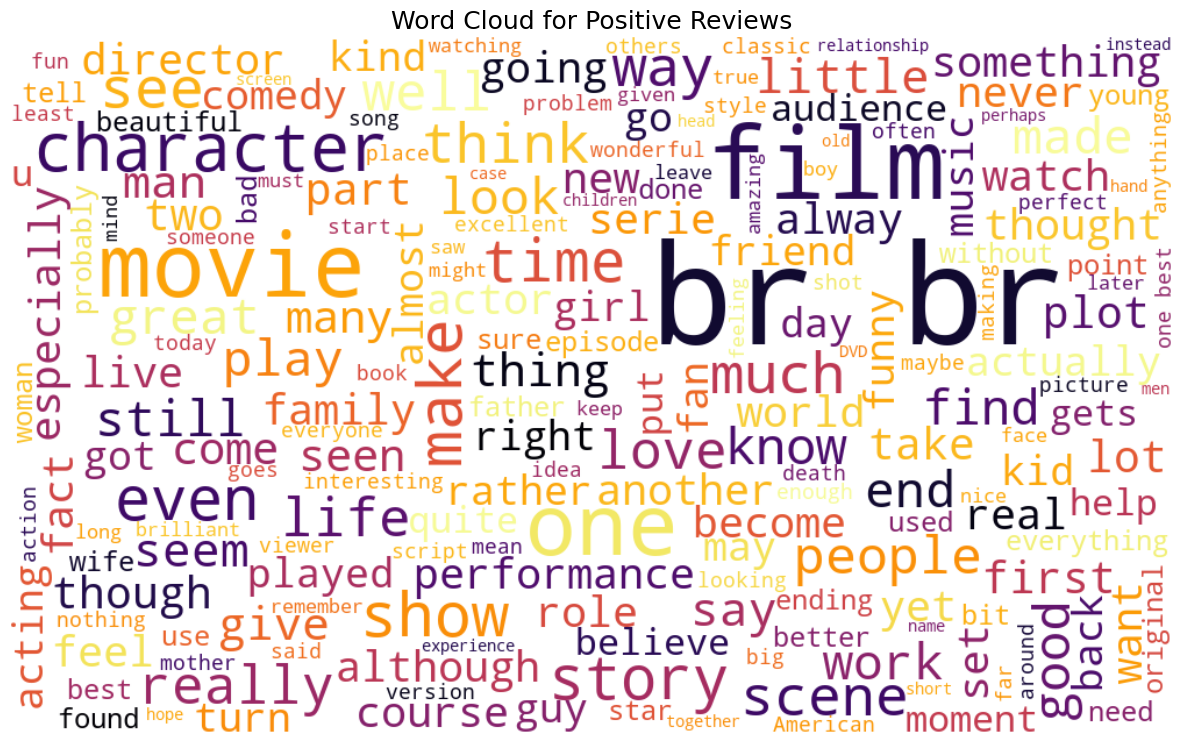

In [24]:
from wordcloud import WordCloud

pos_text = ' '.join(df.query('sentiment == 1')['review'].astype(str))

wc = WordCloud(
    width=1000, height=600,
    max_font_size=120,
    colormap='inferno',
    background_color='white'
).generate(pos_text)

plt.figure(figsize=(15, 10))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews', fontsize=18)
plt.show()


 2.5 DATA CLEANING FOR TEXT

In [25]:
def clean_word(word):
    word = word.lower()
    for symbol in [',', '.', '/', '@', '#', '?']:
       word = word.replace(symbol, f' {symbol} ')
    patterns = [
    r'<[^>]+>',
    r'https?://\S+|www\.\S+',
    r'\d',
    r'[^a-z\s]'
]
    for p in patterns:
      word = re.sub(p, ' ', word)
    word = word.strip()
    return word

In [26]:
ignore_words = set(stopwords.words('english'))
word_cleaner = WordNetLemmatizer()

In [28]:
def clean_up_review(word: str) -> str:
    word = word.lower()
    word = re.sub(r'[^a-z\s]', '', word)
    words = word.split()
    cleaned_words = [
        word_cleaner.lemmatize(w)
        for w in words if w not in ignore_words
    ]
    return ' '.join(cleaned_words)

df['neat_review'] = df['review'].apply(clean_up_review)
print(df[['review', 'neat_review']].head())

                                              review  \
0  One reviewers mentioned watching 1 Oz episode ...   
1  wonderful little production. <br /><br />The f...   
2  thought wonderful way spend time hot summer we...   
3  Basically there's family little boy (Jake) thi...   
4  Petter Mattei's "Love Time Money" visually stu...   

                                         neat_review  
0  one reviewer mentioned watching oz episode hoo...  
1  wonderful little production br br filming tech...  
2  thought wonderful way spend time hot summer we...  
3  basically there family little boy jake think t...  
4  petter matteis love time money visually stunni...  


In [29]:
df['filtered_text'] = df['review'].apply(clean_word)
df['neat_review'] = df['filtered_text'].apply(clean_up_review)
print(df[['review', 'neat_review']].head(5))

                                              review  \
0  One reviewers mentioned watching 1 Oz episode ...   
1  wonderful little production. <br /><br />The f...   
2  thought wonderful way spend time hot summer we...   
3  Basically there's family little boy (Jake) thi...   
4  Petter Mattei's "Love Time Money" visually stu...   

                                         neat_review  
0  one reviewer mentioned watching oz episode hoo...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically family little boy jake think zombie ...  
4  petter mattei love time money visually stunnin...  


# 3. DATA SPLITTING AND LABELS ENCODING

In [30]:
train_reviews, test_reviews, train_sent, test_sent = train_test_split(df['neat_review'], df['sentiment'], test_size=0.3, random_state=42)
print("Train shapes : reviews = {}, sentiment = {}".format(train_reviews.shape,train_sent.shape))
print("Test shapes : reviews = {}, sentiment = {}".format(test_reviews.shape, test_sent.shape))

Train shapes : reviews = (34707,), sentiment = (34707,)
Test shapes : reviews = (14875,), sentiment = (14875,)


In [31]:
cv = TfidfVectorizer(max_features = 5000)

In [32]:
train_reviews_tfid = cv.fit_transform(train_reviews).toarray()
test_reviews_tfid = cv.transform(test_reviews).toarray()

In [33]:
print("Training Set Shape (TF-IDF BOW):", train_reviews_tfid.shape)
print("Testing Set Shape (TF-IDF BOW):", test_reviews_tfid.shape)

Training Set Shape (TF-IDF BOW): (34707, 5000)
Testing Set Shape (TF-IDF BOW): (14875, 5000)


In [34]:
print(f"Training shape - reviews: {train_reviews_tfid.shape}, sent: {train_sent.shape}")
print(f"Testing  shape - reviews: {test_reviews_tfid.shape}, sent: {test_sent.shape}")

Training shape - reviews: (34707, 5000), sent: (34707,)
Testing  shape - reviews: (14875, 5000), sent: (14875,)


In [35]:
print("Shape of TF–IDF Feature Matrix:", train_reviews_tfid.shape)


Shape of TF–IDF Feature Matrix: (34707, 5000)


# 4. MODEL TRAINING + EVALUATION

In [41]:
def show_confusion(y_true, y_pred, model, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred, labels = model.classes_)
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(title, fontsize=14)
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    display.plot()
    plt.show()


Logistic Regression Results:
Accuracy: 0.8876
Precision: 0.8802
Recall: 0.8985
F1 Score: 0.8893


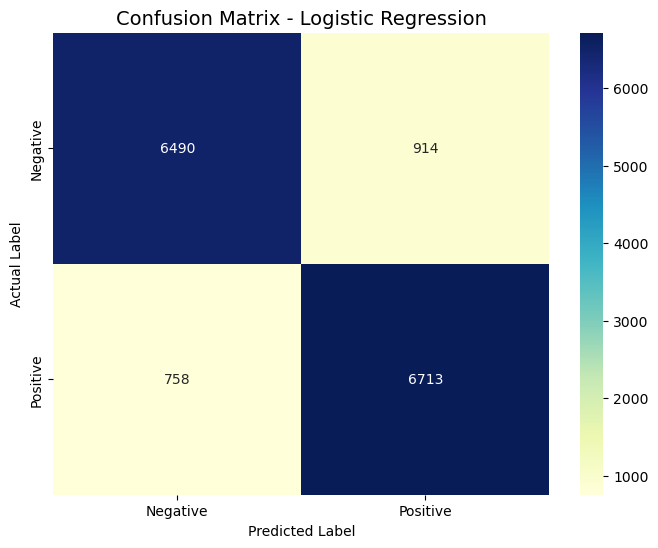

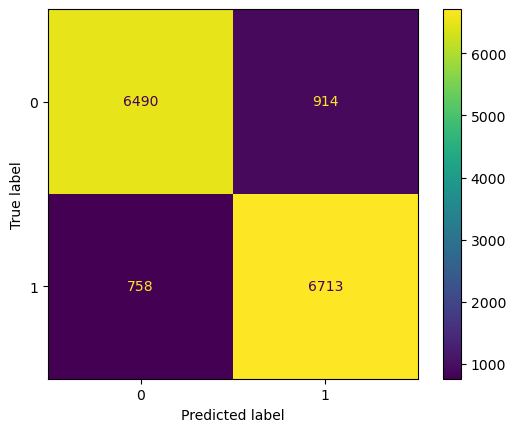

Classification Report of Logistic Regression:
               precision    recall  f1-score   support

           0       0.90      0.88      0.89      7404
           1       0.88      0.90      0.89      7471

    accuracy                           0.89     14875
   macro avg       0.89      0.89      0.89     14875
weighted avg       0.89      0.89      0.89     14875



In [44]:
# Building and trainning the Logistic Regression model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(train_reviews_tfid, train_sent)
# Predicting sentiment labels for the test set
y_pred = logreg.predict(test_reviews_tfid)
# Calculating key performance metrics
metrics = {
    'Accuracy': accuracy_score(test_sent, y_pred),
    'Precision': precision_score(test_sent, y_pred),
    'Recall': recall_score(test_sent, y_pred),
    'F1 Score': f1_score(test_sent, y_pred)
}
# Displaying overall results of the model
print("\nLogistic Regression Results:")
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

# Confusion Matrix of Logistic Regression
show_confusion(test_sent, y_pred, logreg, title='Confusion Matrix - Logistic Regression')

# Classification report of Logistic Regression
clf_report = classification_report(test_sent, y_pred)
print("Classification Report of Logistic Regression:\n", clf_report)



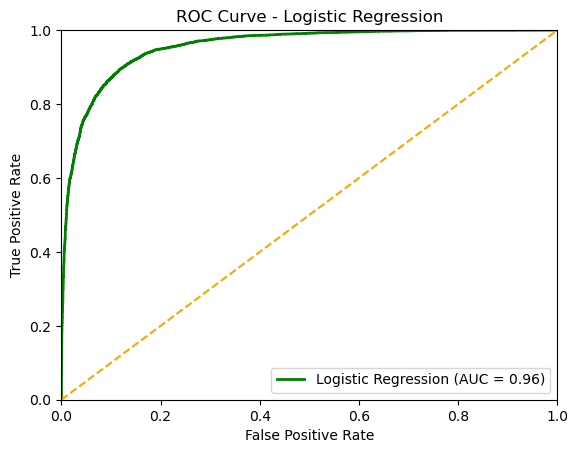

In [45]:
# ROC Curve - Logistic Regression
y_prob = logreg.predict_proba(test_reviews_tfid)[:, 1]
fpr, tpr, _ = roc_curve(test_sent, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='green', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='orange', linestyle='--')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.show()

In [47]:
for i in random.sample(range(len(test_sent)), random.randint(1, 10)):
    print(f"\nReview {i+1}")
    print("Text:", test_reviews.iloc[i])
    pred = "positive" if y_pred[i] == 1 else "negative"
    actual = "positive" if test_sent.iloc[i] == 1 else "negative"
    print(f"Predicted: {pred} <> Actual: {actual}")


Review 5296
Text: love knotts let say front enormous talent best portray nervous lovably befuddled loser thrown position authority fabulous role roy fleming reluctant astronaut film pretty dull really even though kid brother delighted watching film still worth watching really film best enjoyed child categorize family friendly something could sit watch kid family night knotts film great cast beloved character actor help smile knotts give one shaky open mouthed stare matter old jaded adult perspective one thing think great film capture nasa new modern building hope optimism future surprised suave studly leslie neilsen back complaint story roy love interest rather threadbare unlikeable woman give time day becomes big shot like hoping give shove end beware whistling theme tune day watching catchy
Predicted: positive <> Actual: negative

Review 8908
Text: nora single mother two still want live life young artist friend group writer singer actor free love philosophy quite system nora count f


Running MultinomialNB...
MultinomialNB Accuracy: 0.8538
MultinomialNB Precision: 0.8492
MultinomialNB Recall: 0.8619
MultinomialNB F1 Score: 0.8555

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.85      0.85      7404
           1       0.85      0.86      0.86      7471

    accuracy                           0.85     14875
   macro avg       0.85      0.85      0.85     14875
weighted avg       0.85      0.85      0.85     14875



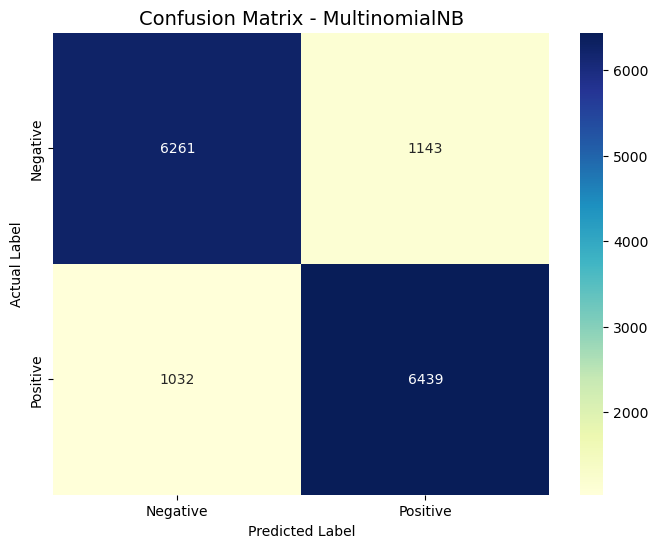

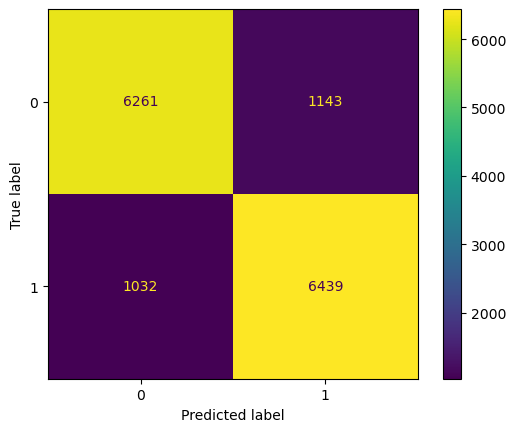

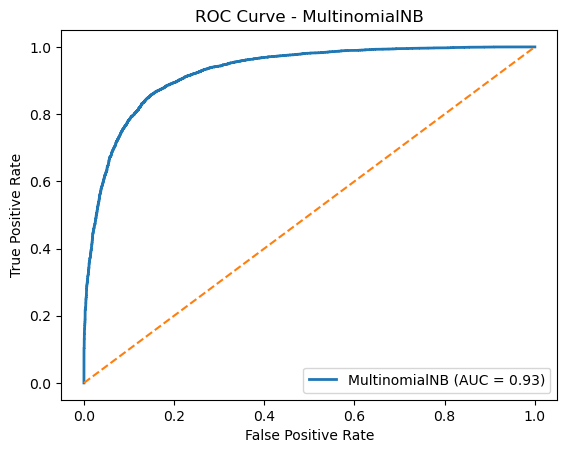


Running GaussianNB...
GaussianNB Accuracy: 0.7951
GaussianNB Precision: 0.7992
GaussianNB Recall: 0.7907
GaussianNB F1 Score: 0.7949

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.80      0.80      7404
           1       0.80      0.79      0.79      7471

    accuracy                           0.80     14875
   macro avg       0.80      0.80      0.80     14875
weighted avg       0.80      0.80      0.80     14875



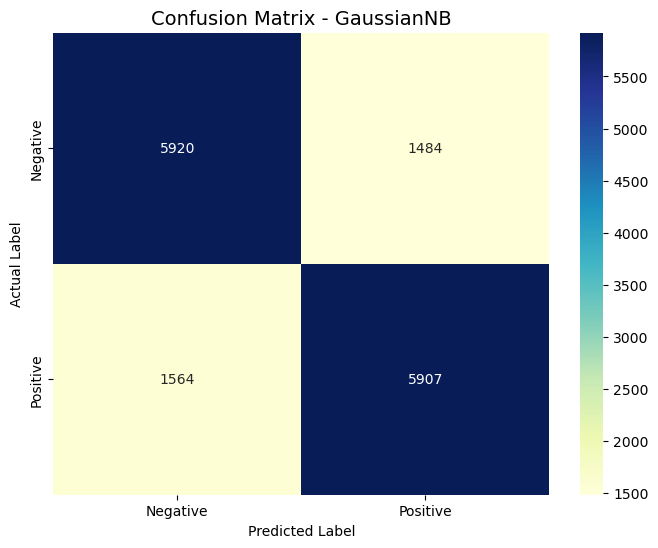

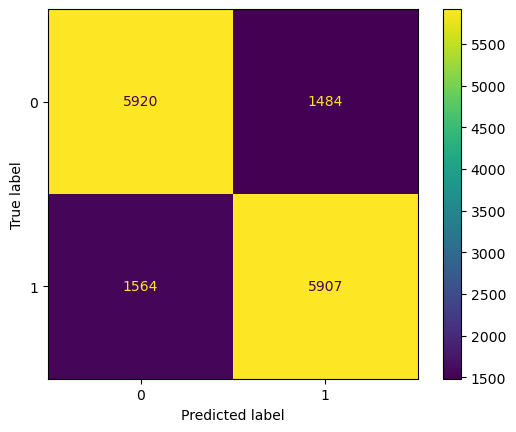

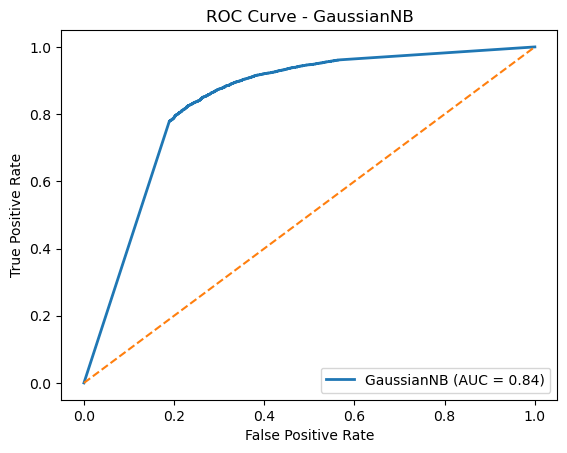


Running BernoulliNB...
BernoulliNB Accuracy: 0.8520
BernoulliNB Precision: 0.8542
BernoulliNB Recall: 0.8506
BernoulliNB F1 Score: 0.8524

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      7404
           1       0.85      0.85      0.85      7471

    accuracy                           0.85     14875
   macro avg       0.85      0.85      0.85     14875
weighted avg       0.85      0.85      0.85     14875



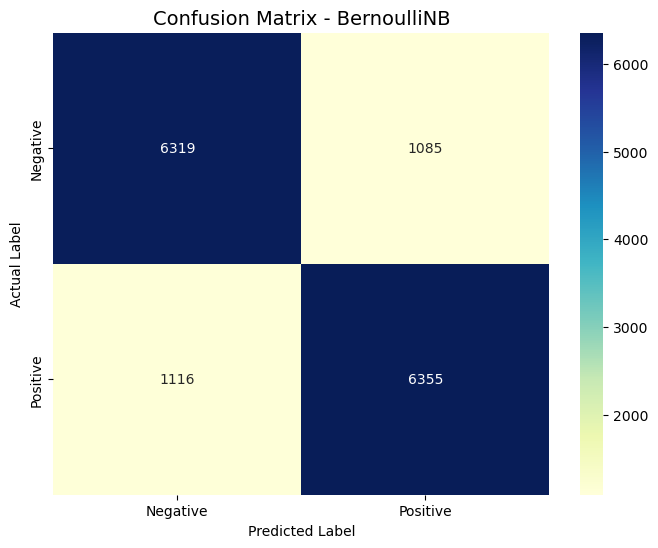

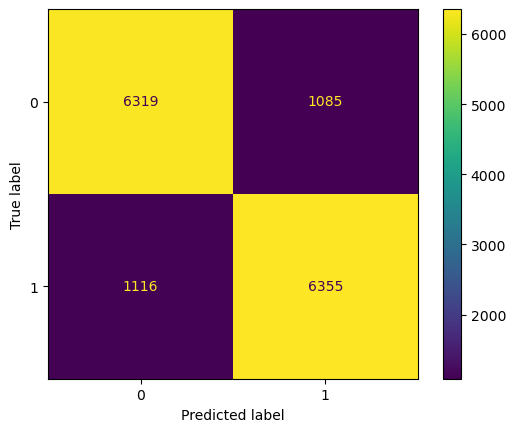

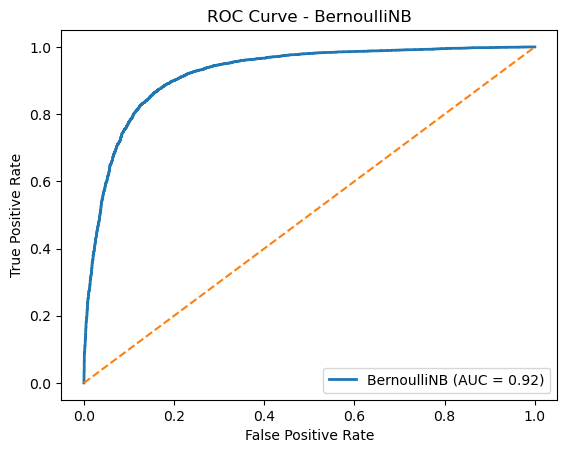

In [50]:
# Defining different Naive Bayes models for comparison
models = {
    'MultinomialNB': MultinomialNB(),
    'GaussianNB': GaussianNB(),
    'BernoulliNB': BernoulliNB()
}
# Looping through each model to train, test, and evaluate
for name, model in models.items():
    print(f"\nRunning {name}...")
# Converting sparse matrices to dense format if required by GaussianNB
    X_train = train_reviews_tfid.toarray() if (name == 'GaussianNB' and sparse.issparse(train_reviews_tfid)) else train_reviews_tfid
    X_test = test_reviews_tfid.toarray() if (name == 'GaussianNB' and sparse.issparse(test_reviews_tfid)) else test_reviews_tfid
# Training the model and making predictions
    model.fit(X_train, train_sent)
    prediction = model.predict(X_test)
# Evaluate performance metrics
    acc = accuracy_score(test_sent, prediction)
    preci = precision_score(test_sent, prediction)
    recall = recall_score(test_sent, prediction)
    f1 = f1_score(test_sent, prediction)

    print(f"{name} Accuracy: {acc:.4f}")
    print(f"{name} Precision: {preci:.4f}")
    print(f"{name} Recall: {recall:.4f}")
    print(f"{name} F1 Score: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(test_sent, prediction))

    # Confusion Matrix of Naive Bayes models
    show_confusion(test_sent, prediction, model, title=f'Confusion Matrix - {name}')
    # ROC Curve of Naive Bayes models
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(test_sent, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], linestyle='--')
        plt.title(f'ROC Curve - {name}')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc='lower right')
        plt.show()
    else:
        print(f"{name} does not support probability predictions.")



In [51]:
for i in random.sample(range(len(test_sent)), random.randint(1, 10)):
    print(f"\nReview {i+1}")
    print("Text:", test_reviews.iloc[i])
    pred = "positive" if y_pred[i] == 1 else "negative"
    actual = "positive" if test_sent.iloc[i] == 1 else "negative"
    print(f"Predicted: {pred} <> Actual: {actual}")


Review 10957
Text: first saw movie back freshman year high school lifetime first saw thought wonderful sure may run longer accurate opinion regardless anyone else may think cynthia gibb great portraying karen mitchell anderson okay richard louise fletcher yes played nurse ratched one flew cuckoo nest fine well found version agnes karen richard mother little bit control freak extremely huge fan carpenter believe karen voice still wonderful really saddens fact gone left earth soon thanks never ending popularity music angelic voice music live anyway back track movie really mystery possibly people fan non fan carpenter caused karen end getting problem health medium responsible karen decision would believe decision could medium one article printed somewhere hit close came shown film moment movie well richard struggle drug karen brief marriage hear loss february yet watching news found year later know another movie carpenter karen made future movie fine say though karen disregarded false de